<a href="https://colab.research.google.com/github/LeoTognola/Cs.-Datos/blob/main/LET_Curso_UNCA_2026_CsDatos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## ⚙️ Instalación y configuración inicial

In [1]:
# Instalamos las librerías necesarias (algunas ya vienen en Colab)
#scikit-learn--> Machine Learning
#panda --> tabla  con filas y columnas etiquetadas (el equivalente exacto a una planilla de Excel).
#matplotlib--> crear gráficos y visualizaciones de datos
#seaborn--> creación de gráficos Estadísticos
#plotly--> gráficos interactivos.
!pip install -q scikit-learn pandas matplotlib seaborn plotly

In [2]:
# Importamos todo lo que vamos a usar en la clase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
#Importa dos herramientas para preparar los datos antes de entrenar un modelo
#StandardScaler--> estandarizar variables numéricas
#LabelEncoder--> Convierte variables categóricas en números
from sklearn.preprocessing import StandardScaler, LabelEncoder
#Importa el algoritmo K-Means.
from sklearn.cluster import KMeans
#Se utiliza para reducir la cantidad de variables.
from sklearn.decomposition import PCA
#Sirve para dividir un conjunto de datos en: entrenamiento y prueba
from sklearn.model_selection import train_test_split
#Importa el algoritmo de regresión lineal.
from sklearn.linear_model import LinearRegression
#Importa funciones para evaluar modelos.
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, r2_score)

# Configuración visual fondo blanco con líneas de cuadrícula.
# palette='muted--> utiliza colores suaves
sns.set_theme(style='whitegrid', palette='muted') # muted: atenuado / deep: x defecto, colores solidos / bright: intenso / dark, etc.
#ancho = 10 pulgadas alto = 5 pulgadas
plt.rcParams['figure.figsize'] = (10, 5)
#muestre hasta 20 columnas
pd.set_option('display.max_columns', 20)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta = '/content/drive/MyDrive/Colab Notebooks/Global Development Indicators 2000_2020.csv'

df = pd.read_csv(ruta)

In [5]:
# pd.read_csv() lee un archivo CSV y lo convierte en DataFrame
df = pd.read_csv(ruta)

print('📊 Archivo cargado:')
print(f'  Global Development Indicators: {df.shape[0]} filas × {df.shape[1]} columnas')

📊 Archivo cargado:
  Global Development Indicators: 5556 filas × 47 columnas


### 1.3 — Exploración inicial: los comandos esenciales

In [6]:
# .head() → primeras 5 filas (vista rápida de la estructura)
df.head()

,year,country_code,country_name,region,income_group,currency_unit,gdp_usd,population,gdp_per_capita,inflation_rate,...,education_health_ratio,years_since_2000,years_since_century,is_pandemic_period,human_development_index,climate_vulnerability_index,digital_readiness_score,governance_quality_index,global_resilience_score,global_development_resilience_index
0,2000,AFE,Africa Eastern and Southern,NaN,NaN,NaN,2.839525e+11,398113044.0,713.245921,8.601485,...,NaN,0,0,0,0.075174,0.252217,0.012104,0.5,0.134733,12.302733
1,2001,AFE,Africa Eastern and Southern,NaN,NaN,NaN,2.588432e+11,408522129.0,633.608789,5.840354,...,NaN,1,1,0,0.094327,0.238820,0.016189,0.5,0.067481,13.257762
2,2002,AFE,Africa Eastern and Southern,NaN,NaN,NaN,2.648950e+11,419223717.0,631.870340,8.763752,...,NaN,2,2,0,0.114721,0.241795,0.020744,0.5,0.066218,13.962528
3,2003,AFE,Africa Eastern and Southern,NaN,NaN,NaN,3.526921e+11,430246635.0,819.743981,7.449700,...,NaN,3,3,0,0.135402,0.243486,0.027147,0.5,0.146931,15.163578
4,2004,AFE,Africa Eastern and Southern,NaN,NaN,NaN,4.388756e+11,441630149.0,993.762711,5.023421,...,NaN,4,4,0,0.155819,0.247210,0.035082,0.5,0.191834,16.111022


In [7]:
# .info() → tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5556 entries, 0 to 5555
Data columns (total 47 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   year                                 5556 non-null   int64  
 1   country_code                         5556 non-null   object 
 2   country_name                         5556 non-null   object 
 3   region                               4548 non-null   object 
 4   income_group                         4527 non-null   object 
 5   currency_unit                        4548 non-null   object 
 6   gdp_usd                              5332 non-null   float64
 7   population                           5556 non-null   float64
 8   gdp_per_capita                       5332 non-null   float64
 9   inflation_rate                       4746 non-null   float64
 10  unemployment_rate                    4926 non-null   float64
 11  fdi_pct_gdp                   

In [8]:
# .describe() → estadísticas descriptivas de columnas numéricas
#solo analiza columnas que contienen datos numéricos
df.describe().round(2)

,year,gdp_usd,population,gdp_per_capita,inflation_rate,unemployment_rate,fdi_pct_gdp,co2_emissions_kt,energy_use_per_capita,renewable_energy_pct,...,education_health_ratio,years_since_2000,years_since_century,is_pandemic_period,human_development_index,climate_vulnerability_index,digital_readiness_score,governance_quality_index,global_resilience_score,global_development_resilience_index
count,5556.00,5.332000e+03,5.556000e+03,5332.00,4746.00,4926.00,5011.00,4534.00,2935.00,4808.00,...,3619.00,5556.00,5556.00,5556.00,4956.00,5556.00,5556.00,5556.0,4831.00,5556.00
mean,2009.99,2.008355e+12,2.803412e+08,13795.82,5.67,7.93,8.26,1121547.89,2348.10,30.14,...,8.11,9.99,9.99,0.05,0.66,0.36,0.37,0.5,0.44,37.86
std,6.06,7.293769e+12,8.833686e+08,21800.21,17.19,5.70,57.78,3581651.50,2792.39,29.06,...,10.25,6.06,6.06,0.21,0.27,0.10,0.29,0.0,0.28,17.96
min,2000.00,1.319654e+07,9.392000e+03,111.93,-18.11,0.10,-1275.19,0.00,9.55,0.00,...,0.03,0.00,0.00,0.00,-0.26,0.05,0.00,0.5,-2.75,-3.50
25%,2005.00,6.030846e+09,1.362497e+06,1444.89,1.75,4.21,1.42,2652.50,632.68,5.37,...,1.02,5.00,5.00,0.00,0.48,0.28,0.09,0.5,0.35,25.20
50%,2010.00,3.792200e+10,9.460952e+06,4613.06,3.38,6.26,2.81,26410.00,1327.50,20.09,...,3.80,10.00,10.00,0.00,0.68,0.37,0.33,0.5,0.43,36.72
75%,2015.00,4.327084e+11,5.915911e+07,16338.37,6.13,10.22,5.30,286835.00,3060.16,50.83,...,11.07,15.00,15.00,0.00,0.89,0.44,0.62,0.5,0.57,49.45
max,2020.00,8.756805e+13,7.761620e+09,189487.15,557.20,37.25,1709.77,34041045.97,22120.43,98.34,...,64.51,20.00,20.00,1.00,1.17,0.50,1.57,0.5,1.55,100.49


In [9]:
# ¿Cuántos valores faltantes tiene cada columna?
print('Valores nulos por columna:')
print(df.isnull().sum())

print('\n¿Qué porcentaje representan?')
#pct_nulos --> lista de n posiciones. n = n° columnas de df_models
pct_nulos = (df.isnull().sum() / len(df) * 100).round(1)


print(pct_nulos[pct_nulos > 0])

Valores nulos por columna:
year                                      0
country_code                              0
country_name                              0
region                                 1008
income_group                           1029
currency_unit                          1008
gdp_usd                                 224
population                                0
gdp_per_capita                          224
inflation_rate                          810
unemployment_rate                       630
fdi_pct_gdp                             545
co2_emissions_kt                       1022
energy_use_per_capita                  2621
renewable_energy_pct                    748
forest_area_pct                         113
electricity_access_pct                  401
life_expectancy                         600
child_mortality                         504
school_enrollment_secondary            1800
health_expenditure_pct_gdp              870
hospital_beds_per_1000                 2873
physi

In [10]:
# Explorar variables categóricas

# Regiones
print('Regiones:', df['region'].unique())

print('\nConteo por región:')
print(df['region'].value_counts())

Regiones: [nan 'East Asia & Pacific' 'Europe & Central Asia'
 'Latin America & Caribbean' 'Middle East & North Africa' 'North America'
 'South Asia' 'Sub-Saharan Africa']

Conteo por región:
region
Europe & Central Asia         1218
Sub-Saharan Africa             999
Latin America & Caribbean      882
East Asia & Pacific            777
Middle East & North Africa     441
South Asia                     168
North America                   63
Name: count, dtype: int64


In [11]:
# Explorar variables categóricas

# Código de país
print('Códigos de país:', df['country_code'].unique())
print('\nConteo por código de país:')
print(df['country_code'].value_counts())


Códigos de país: ['AFE' 'AFW' 'ARB' 'CEB' 'CSS' 'EAP' 'EAR' 'EAS' 'ECA' 'ECS' 'EMU' 'EUU'
 'FCS' 'HIC' 'HPC' 'IBD' 'IBT' 'IDA' 'IDB' 'IDX' 'LAC' 'LCN' 'LDC' 'LIC'
 'LMC' 'LMY' 'LTE' 'MEA' 'MIC' 'MNA' 'NAC' 'OED' 'OSS' 'PRE' 'PSS' 'PST'
 'SAS' 'SSA' 'SSF' 'SST' 'TEA' 'TEC' 'TLA' 'TMN' 'TSA' 'TSS' 'UMC' 'WLD'
 'ASM' 'AUS' 'BRN' 'CHN' 'FJI' 'FSM' 'GUM' 'HKG' 'IDN' 'JPN' 'KHM' 'KIR'
 'KOR' 'LAO' 'MAC' 'MHL' 'MMR' 'MNG' 'MNP' 'MYS' 'NCL' 'NRU' 'NZL' 'PHL'
 'PLW' 'PNG' 'PRK' 'PYF' 'SGP' 'SLB' 'THA' 'TLS' 'TON' 'TUV' 'VNM' 'VUT'
 'WSM' 'ALB' 'AND' 'ARM' 'AUT' 'AZE' 'BEL' 'BGR' 'BIH' 'BLR' 'CHE' 'CHI'
 'CYP' 'CZE' 'DEU' 'DNK' 'ESP' 'EST' 'FIN' 'FRA' 'FRO' 'GBR' 'GEO' 'GIB'
 'GRC' 'GRL' 'HRV' 'HUN' 'IMN' 'IRL' 'ISL' 'ITA' 'KAZ' 'KGZ' 'LIE' 'LTU'
 'LUX' 'LVA' 'MCO' 'MDA' 'MKD' 'MNE' 'NLD' 'NOR' 'POL' 'PRT' 'ROU' 'RUS'
 'SMR' 'SRB' 'SVK' 'SVN' 'SWE' 'TJK' 'TKM' 'TUR' 'UKR' 'UZB' 'XKX' 'ABW'
 'ARG' 'ATG' 'BHS' 'BLZ' 'BOL' 'BRA' 'BRB' 'CHL' 'COL' 'CRI' 'CUB' 'CUW'
 'CYM' 'DMA' 'DOM' 'ECU' 'GRD' 'GT

In [12]:
# Nombre del país
print('\nNombres de países:', df['country_name'].unique())
print('\nConteo por país:')
print(df['country_name'].value_counts())



Nombres de países: ['Africa Eastern and Southern' 'Africa Western and Central' 'Arab World'
 'Central Europe and the Baltics' 'Caribbean small states'
 'East Asia & Pacific (excluding high income)'
 'Early-demographic dividend' 'East Asia & Pacific'
 'Europe & Central Asia (excluding high income)' 'Europe & Central Asia'
 'Euro area' 'European Union' 'Fragile and conflict affected situations'
 'High income' 'Heavily indebted poor countries (HIPC)' 'IBRD only'
 'IDA & IBRD total' 'IDA total' 'IDA blend' 'IDA only'
 'Latin America & Caribbean (excluding high income)'
 'Latin America & Caribbean'
 'Least developed countries: UN classification' 'Low income'
 'Lower middle income' 'Low & middle income' 'Late-demographic dividend'
 'Middle East & North Africa' 'Middle income'
 'Middle East & North Africa (excluding high income)' 'North America'
 'OECD members' 'Other small states' 'Pre-demographic dividend'
 'Pacific island small states' 'Post-demographic dividend' 'South Asia'
 'Sub-Sahara

In [13]:
# Grupo de ingresos
print('\nGrupos de ingreso:', df['income_group'].unique())
print('\nConteo por grupo de ingreso:')
print(df['income_group'].value_counts())



Grupos de ingreso: [nan 'Upper middle income' 'High income' 'Lower middle income'
 'Low income']

Conteo por grupo de ingreso:
income_group
High income            1680
Upper middle income    1134
Lower middle income    1134
Low income              579
Name: count, dtype: int64


In [14]:
# Moneda
# print('\nUnidades monetarias:', df['currency_unit'].unique())
# print('\nConteo por moneda:')
# print(df['currency_unit'].value_counts())

> 🧠 **Concepto clave — tipos de datos en ciencia de datos:**
> - **Numéricos continuos**: params_billions, training_cost_usd_est
> - **Numéricos discretos**: release_year, context_window_k_tokens
> - **Categóricos nominales**: model_type, organization, access_type
> - **Fechas**: release_date, training_cutoff_date

---
## 📊 BLOQUE 2 — Visualización de datos

"Un gráfico vale más que mil filas de describe()"

### 2.1 — Distribuciones

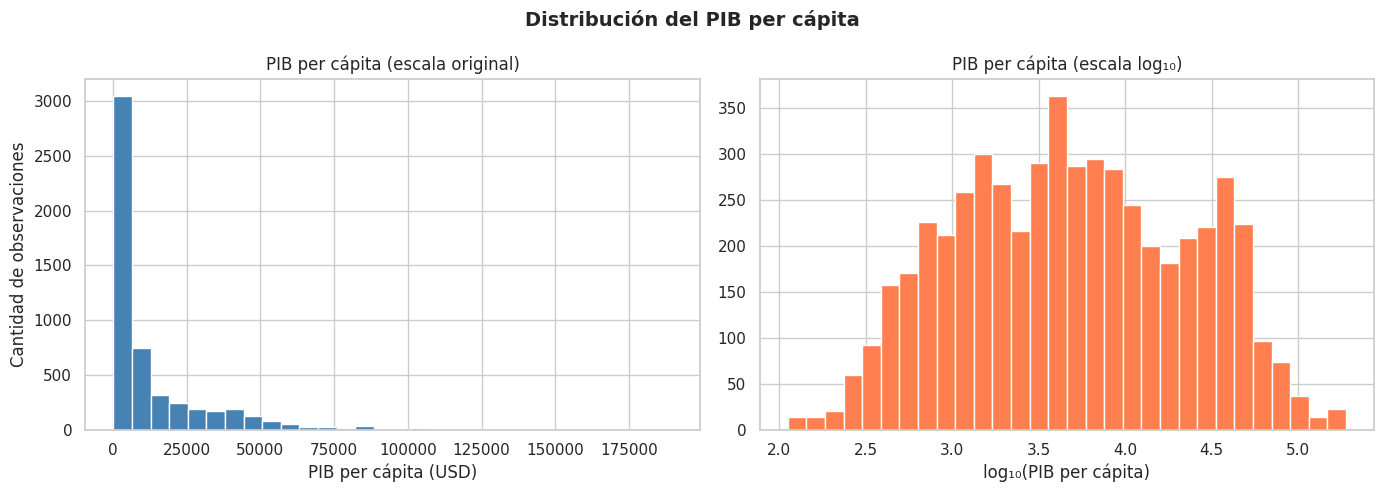

In [15]:
# Histograma: distribución del PIB per cápita

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala original
axes[0].hist(
    df['gdp_per_capita'].dropna(),
    bins=30,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('PIB per cápita (escala original)')
axes[0].set_xlabel('PIB per cápita (USD)')
axes[0].set_ylabel('Cantidad de observaciones')

# Escala logarítmica
axes[1].hist(
    np.log10(df['gdp_per_capita'].dropna() + 0.001),
    bins=30,
    color='coral',
    edgecolor='white'
)
axes[1].set_title('PIB per cápita (escala log₁₀)')
axes[1].set_xlabel('log₁₀(PIB per cápita)')

plt.suptitle(
    'Distribución del PIB per cápita',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# print('\n💡 La escala logarítmica es útil cuando los datos abarcan varios órdenes de magnitud.')

### 2.2 — Comparación entre grupos

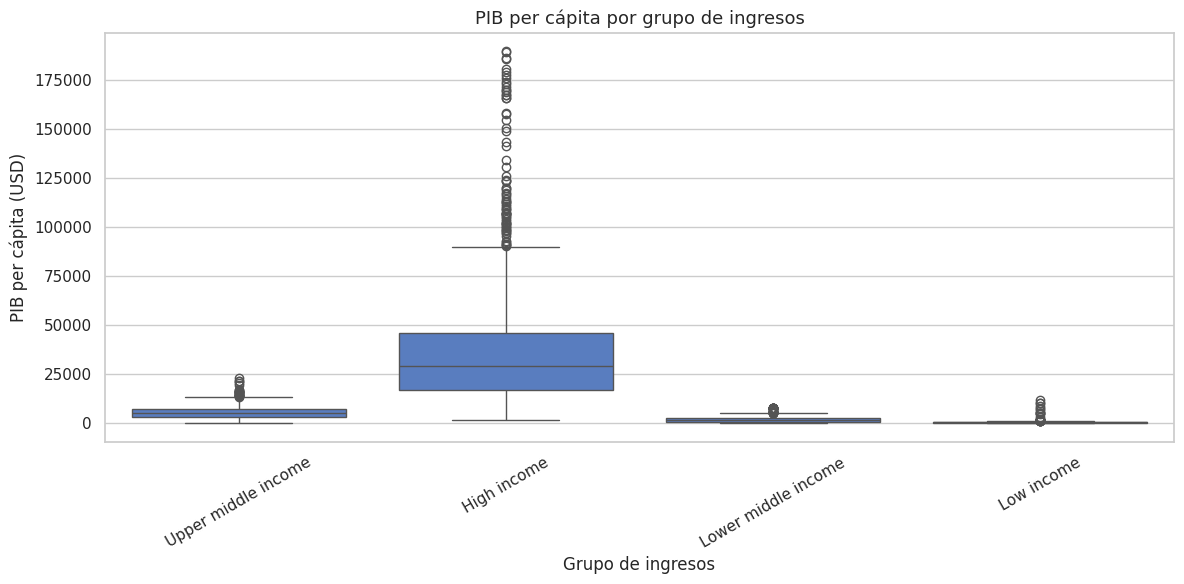

In [16]:
# Boxplot: PIB per cápita por grupo de ingresos PREGUNTAR$$$$$$$$$$$$$$$$$$$$

# Seleccionamos los grupos de ingresos más frecuentes
top_income_groups = df['income_group'].value_counts().head(6).index

# Filtramos la base para quedarnos con esos grupos
df_top = df[df['income_group'].isin(top_income_groups)].copy()

# Creamos el gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_top,
    x='income_group',
    y='gdp_per_capita',
    ax=ax
)

ax.set_title('PIB per cápita por grupo de ingresos', fontsize=13)
ax.set_xlabel('Grupo de ingresos')
ax.set_ylabel('PIB per cápita (USD)')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 2.3 — Evolución temporal

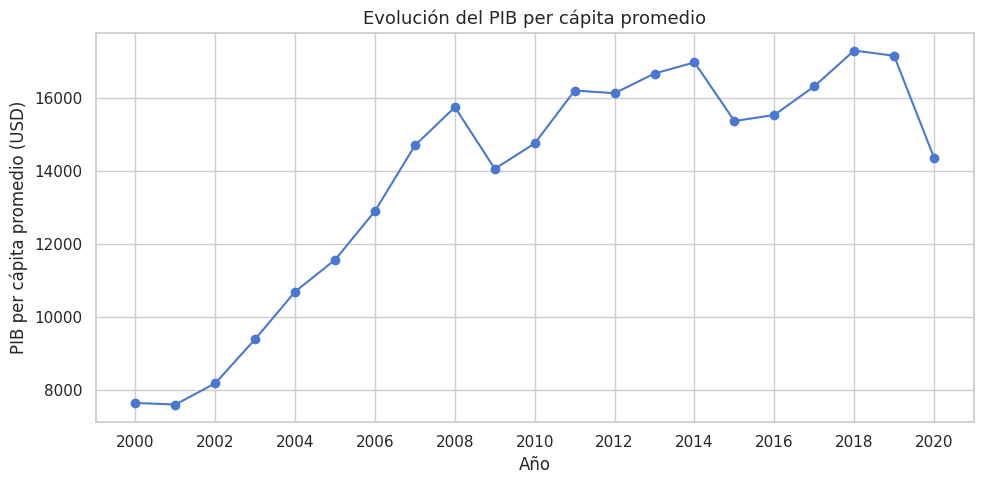

In [17]:
#POSIBLE ALTERNATIVA a Crecimiento en el número de modelos por año ???$$$$$$$$

# Evolución del PIB per cápita promedio por año

gdp_por_año = (
    df.groupby('year')['gdp_per_capita']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    gdp_por_año['year'],
    gdp_por_año['gdp_per_capita'],
    marker='o'
)

ax.set_title('Evolución del PIB per cápita promedio', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('PIB per cápita promedio (USD)')

# Eje X
ax.set_xticks(gdp_por_año['year'][gdp_por_año['year'] % 2 == 0])

plt.tight_layout()
plt.show()

In [18]:
#solo para evaluar la curva anteior

resumen_anual = df.groupby('year').agg(
    cantidad=('gdp_per_capita', 'count'),
    promedio_gdp=('gdp_per_capita', 'mean')
).reset_index()

print(resumen_anual)

    year  cantidad  promedio_gdp
0   2000       247   7644.790352
1   2001       248   7600.427986
2   2002       253   8182.405226
3   2003       253   9391.598104
4   2004       253  10691.920869
5   2005       253  11561.583715
6   2006       254  12897.414185
7   2007       254  14692.141125
8   2008       255  15738.361304
9   2009       255  14052.431399
10  2010       256  14746.832019
11  2011       258  16194.156254
12  2012       257  16120.560273
13  2013       258  16659.720923
14  2014       258  16964.258521
15  2015       257  15359.980640
16  2016       256  15524.456868
17  2017       256  16308.827347
18  2018       256  17288.675629
19  2019       253  17144.609643
20  2020       242  14354.539354


### 2.4 — Correlaciones y relaciones entre variables

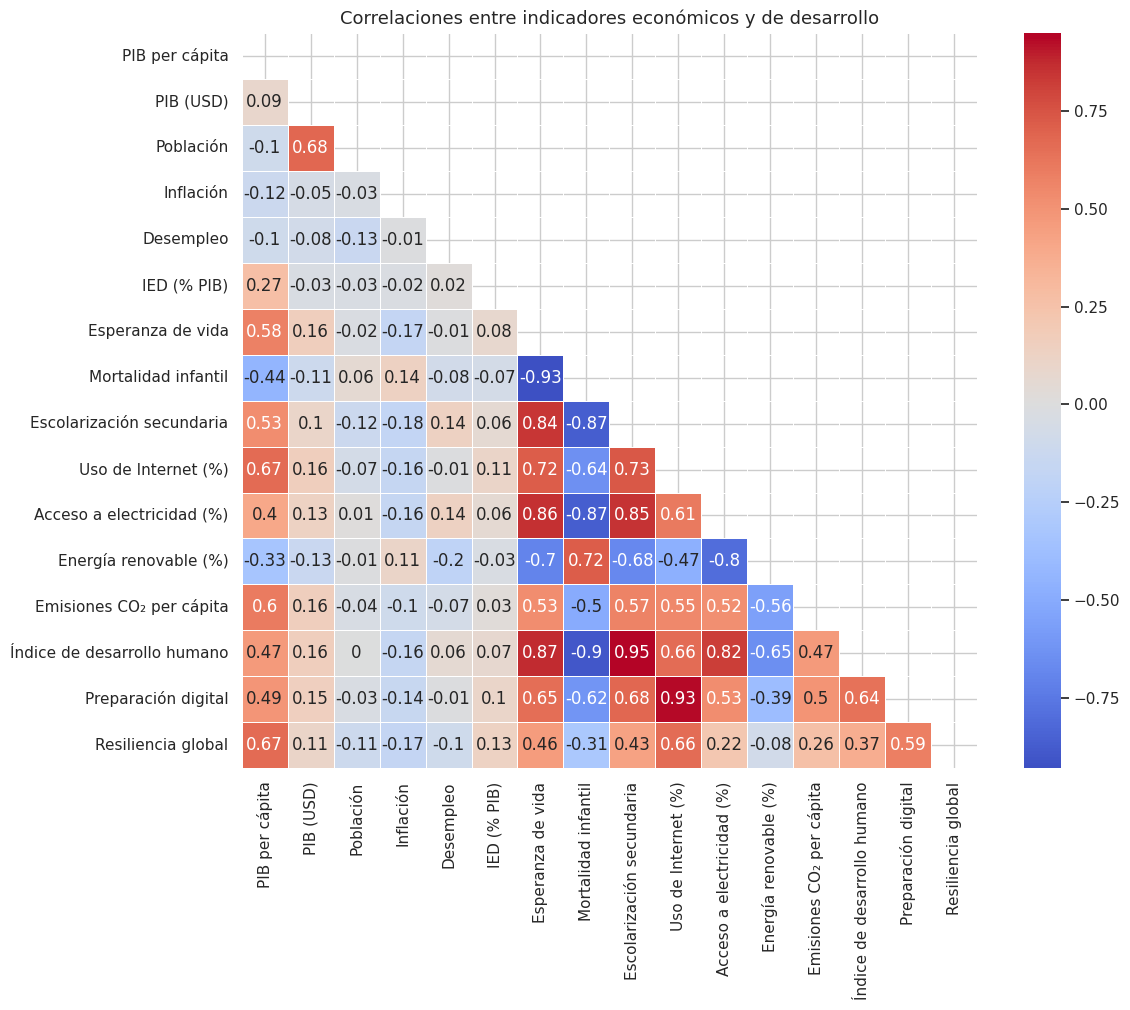

Valores cercanos a 1 o -1 indican fuerte correlación.
Valores cercanos a 0 indican poca o ninguna relación lineal.


In [19]:
# Heatmap de correlaciones

# Variables numéricas seleccionadas
cols_num = [
    'gdp_per_capita',
    'gdp_usd',
    'population',
    'inflation_rate',
    'unemployment_rate',
    'fdi_pct_gdp',
    'life_expectancy',
    'child_mortality',
    'school_enrollment_secondary',
    'internet_usage_pct',
    'electricity_access_pct',
    'renewable_energy_pct',
    'co2_emissions_per_capita_tons',
    'human_development_index',
    'digital_readiness_score',
    'global_resilience_score'
]

# Nombres que aparecerán en el gráfico
nombres_es = {
    'gdp_per_capita': 'PIB per cápita',
    'gdp_usd': 'PIB (USD)',
    'population': 'Población',
    'inflation_rate': 'Inflación',
    'unemployment_rate': 'Desempleo',
    'fdi_pct_gdp': 'IED (% PIB)',
    'life_expectancy': 'Esperanza de vida',
    'child_mortality': 'Mortalidad infantil',
    'school_enrollment_secondary': 'Escolarización secundaria',
    'internet_usage_pct': 'Uso de Internet (%)',
    'electricity_access_pct': 'Acceso a electricidad (%)',
    'renewable_energy_pct': 'Energía renovable (%)',
    'co2_emissions_per_capita_tons': 'Emisiones CO₂ per cápita',
    'human_development_index': 'Índice de desarrollo humano',
    'digital_readiness_score': 'Preparación digital',
    'global_resilience_score': 'Resiliencia global'
}

# Matriz de correlación de Pearson
corr_matrix = df[cols_num].corr().round(2)

# Equivalentes en español
corr_matrix_es = corr_matrix.rename(
    index=nombres_es,
    columns=nombres_es
)

# Sacar la mitad de arriba
mask = np.triu(
    np.ones_like(corr_matrix_es, dtype=bool)
)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix_es,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5
)

ax.set_title(
    'Correlaciones entre indicadores económicos y de desarrollo',
    fontsize=13
)

plt.tight_layout()
plt.show()

print('Valores cercanos a 1 o -1 indican fuerte correlación.')
print('Valores cercanos a 0 indican poca o ninguna relación lineal.')

---
## 🟠 BLOQUE 4 **(PRINCIPAL - Correcciones)** — Regresión: predecir puntajes de benchmark

### ¿Qué es la regresión?

Es **aprendizaje supervisado**, pero ahora predecimos un **valor numérico continuo** en lugar de una categoría.

```
X (parámetros, flops, año)  →  Modelo  →  ŷ (score MMLU predicho: 73.4%)
```

**Pregunta**: ¿Podemos predecir el rendimiento de un modelo en MMLU a partir de su tamaño y costo computacional?

In [20]:
# Preparar la regresión lineal

from sklearn.linear_model import LinearRegression, Ridge

# Variables
cols_reg = [
    'gdp_per_capita',              # Y=PBI per cápita

    # Variables económicas
    'inflation_rate',
    'unemployment_rate',
    'fdi_pct_gdp',

    # Variables sociales
    'life_expectancy',
    'child_mortality',
    'school_enrollment_secondary',

    # Variables digitales
    'internet_usage_pct',
    'digital_readiness_score',

    # Infraestructura
    'electricity_access_pct'
]

# Eliminar filas incomptas
df_reg = df[cols_reg].dropna()

print(f'Dataset de regresión: {df_reg.shape}')

print(
    f'PIB per cápita → '
    f'min: {df_reg["gdp_per_capita"].min():.2f} USD  '
    f'max: {df_reg["gdp_per_capita"].max():.2f} USD  '
    f'media: {df_reg["gdp_per_capita"].mean():.2f} USD'
)

print('Primeras observaciones:')
print(df_reg.head())

Dataset de regresión: (3157, 10)
PIB per cápita → min: 111.93 USD  max: 123514.20 USD  media: 12410.72 USD
Primeras observaciones:
    gdp_per_capita  inflation_rate  unemployment_rate  fdi_pct_gdp  \
42     2890.227674        1.853790          12.596101     0.471363   
43     2768.502103        1.772204          12.469380     1.116324   
44     2725.609752        1.832994          12.465001     0.768172   
45     2948.632623        2.712592          12.390521     1.646663   
46     3430.982910        3.632280          11.352673     2.027210   

    life_expectancy  child_mortality  school_enrollment_secondary  \
42        67.800591        60.559473                    60.053501   
43        68.072519        58.685003                    61.517052   
44        68.340246        56.840837                    62.593201   
45        68.610506        55.057529                    64.301193   
46        68.886188        53.261499                    65.969116   

    internet_usage_pct  digital_r

In [21]:
#Regresión

features_reg = [
    'inflation_rate',
    'unemployment_rate',
    'fdi_pct_gdp',
    'life_expectancy',
    'child_mortality',
    'school_enrollment_secondary',
    'internet_usage_pct',
    'digital_readiness_score',
    'electricity_access_pct'
]

# Variables X
X_reg = df_reg[features_reg].copy()

# Variable Y
y_reg = df_reg['gdp_per_capita'].values

# Split: 80% entrenamiento / 20% prueba
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Estandarización de las variables
scaler_reg = StandardScaler()

# Calcula media y desviación estándar SOLO con los datos de entrenamiento
X_tr_s = scaler_reg.fit_transform(X_tr)

# Utiliza los mismos parámetros para transformar los datos de prueba
X_te_s = scaler_reg.transform(X_te)

# Cantidad de observaciones en cada conjunto
print(f'Train: {len(X_tr)} | Test: {len(X_te)}')

Train: 2525 | Test: 632


In [22]:
# Modelo 1: Regresión Lineal

# Modelo de Regresión Lineal
lr = LinearRegression()

# Entrenar el modelo
lr.fit(X_tr_s, y_tr)

# Predicciones
y_pred_lr = lr.predict(X_te_s)

# RMSE
rmse_lr = np.sqrt(mean_squared_error(y_te, y_pred_lr))

# R²
r2_lr = r2_score(y_te, y_pred_lr)

print('Regresión Lineal:')
print(f'RMSE: {rmse_lr:.2f} USD')
print(f'R²:   {r2_lr:.3f}')

print('Interpretación:')
print(f'El modelo explica el {r2_lr*100:.1f}% de la variabilidad del PIB per cápita.')
print(f'El RMSE es de ±{rmse_lr:.2f} USD.')

print('Coeficientes:')
coefs = pd.Series(lr.coef_, index=features_reg).sort_values()
print(coefs)

Regresión Lineal:
RMSE: 10135.73 USD
R²:   0.681
Interpretación:
El modelo explica el 68.1% de la variabilidad del PIB per cápita.
El RMSE es de ±10135.73 USD.
Coeficientes:
digital_readiness_score        -6611.730890
electricity_access_pct         -5638.681534
unemployment_rate              -1179.456092
inflation_rate                  -141.301326
fdi_pct_gdp                      403.026820
child_mortality                 6592.962182
school_enrollment_secondary     6653.542190
life_expectancy                10103.505540
internet_usage_pct             14554.638322
dtype: float64


In [23]:
# Transformación logarítmica del PIB per cápita
y_log = np.log10(df_reg['gdp_per_capita'].values)

In [24]:
# Usamos los mismos índices de train y test
X_tr_log, X_te_log, y_tr_log, y_te_log = train_test_split(
    X_reg,
    y_log,
    test_size=0.2,
    random_state=42
)

# Estandarizamos X usando solamente el conjunto de entrenamiento
scaler_log = StandardScaler()

X_tr_log_s = scaler_log.fit_transform(X_tr_log)
X_te_log_s = scaler_log.transform(X_te_log)

In [25]:
# Modelo de regresión lineal con Y transformada
lr_log = LinearRegression()

lr_log.fit(X_tr_log_s, y_tr_log)

# Predicciones
y_pred_log = lr_log.predict(X_te_log_s)

In [26]:
# Evaluación
rmse_log = np.sqrt(mean_squared_error(y_te_log, y_pred_log))
r2_log = r2_score(y_te_log, y_pred_log)

print('Regresión Lineal con PIB per cápita en escala logarítmica:')
print(f'RMSE: {rmse_log:.3f}')
print(f'R²:   {r2_log:.3f}')

Regresión Lineal con PIB per cápita en escala logarítmica:
RMSE: 0.262
R²:   0.837


In [27]:
# R² ajustado
n = len(y_te_log)
p = X_te_log.shape[1]

r2_ajustado_log = 1 - (1 - r2_log) * (n - 1) / (n - p - 1)

print(f'R²:           {r2_log:.3f}')
print(f'R² ajustado:  {r2_ajustado_log:.3f}')

R²:           0.837
R² ajustado:  0.835


In [28]:
coefs_log = pd.Series(
    lr_log.coef_,
    index=features_reg
).sort_values()

print('Coeficientes del modelo logarítmico:')
print(coefs_log)

Coeficientes del modelo logarítmico:
inflation_rate                -0.026738
unemployment_rate              0.001975
fdi_pct_gdp                    0.014946
electricity_access_pct         0.045105
digital_readiness_score        0.048471
child_mortality                0.068406
life_expectancy                0.181557
school_enrollment_secondary    0.211929
internet_usage_pct             0.212685
dtype: float64


In [29]:
!pip install -q statsmodels

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculamos VIF para las variables predictoras
vif_data = pd.DataFrame()

vif_data['Variable'] = features_reg

vif_data['VIF'] = [
    variance_inflation_factor(X_tr_s, i)
    for i in range(X_tr_s.shape[1])
]

print(vif_data.sort_values('VIF', ascending=False))

                      Variable        VIF
6           internet_usage_pct  12.700247
4              child_mortality  12.058409
3              life_expectancy  11.916553
7      digital_readiness_score  10.796987
8       electricity_access_pct   6.521034
5  school_enrollment_secondary   6.325993
1            unemployment_rate   1.199095
0               inflation_rate   1.110911
2                  fdi_pct_gdp   1.023412


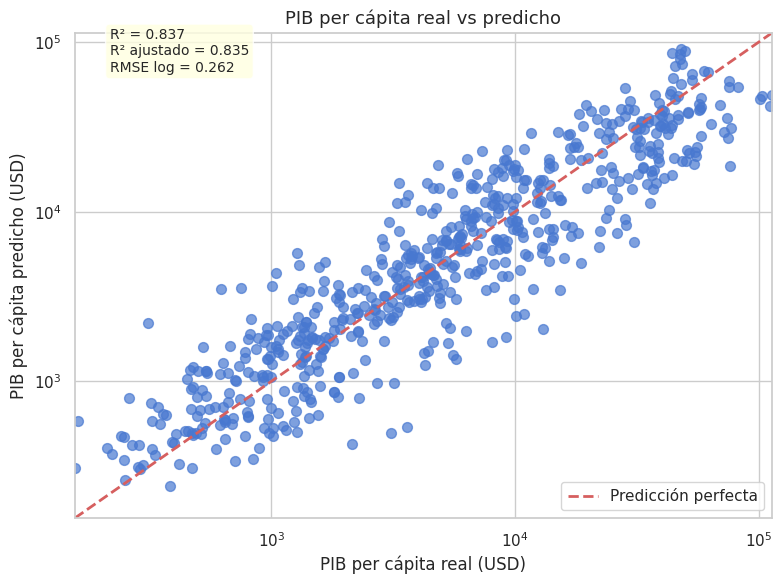

Cuanto más cerca estén los puntos de la línea roja, más precisas son las predicciones.


In [30]:
# Valores reales y predichos, nuevamente expresados en USD
y_real_usd = 10 ** y_te_log
y_pred_usd = 10 ** y_pred_log

# Gráfico: valores reales vs predichos
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    y_real_usd,
    y_pred_usd,
    alpha=0.7,
    s=50
)

# Línea ideal: predicción perfecta
lim = [
    min(y_real_usd.min(), y_pred_usd.min()),
    max(y_real_usd.max(), y_pred_usd.max())
]

ax.plot(
    lim,
    lim,
    'r--',
    linewidth=2,
    label='Predicción perfecta'
)

# Escala logarítmica para ambos ejes
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(lim)
ax.set_ylim(lim)

ax.set_title(
    'PIB per cápita real vs predicho',
    fontsize=13
)

ax.set_xlabel('PIB per cápita real (USD)')
ax.set_ylabel('PIB per cápita predicho (USD)')

ax.legend()

# Mostrar las métricas
ax.text(
    0.05,
    0.92,
    f'R² = {r2_log:.3f}\n'
    f'R² ajustado = {r2_ajustado_log:.3f}\n'
    f'RMSE log = {rmse_log:.3f}',
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(
        boxstyle='round',
        facecolor='lightyellow',
        alpha=0.8
    )
)

plt.tight_layout()
plt.show()

print('Cuanto más cerca estén los puntos de la línea roja, más precisas son las predicciones.')

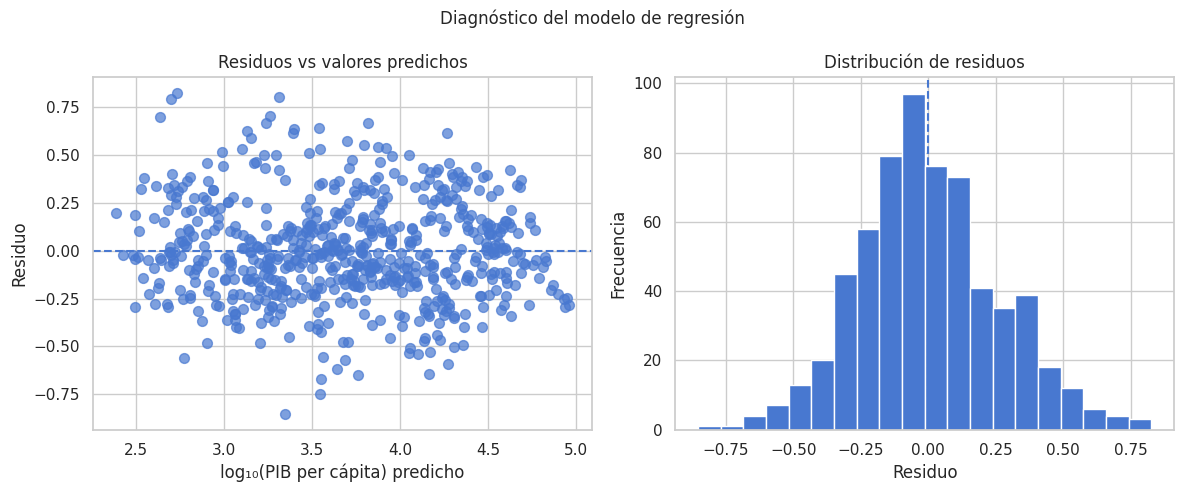

In [31]:
# Análisis de residuos del modelo logarítmico
# Residuo = valor real - valor predicho
residuos_log = y_te_log - y_pred_log

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# 1. Residuos vs valores predichos
axes[0].scatter(
    y_pred_log,
    residuos_log,
    alpha=0.7,
    s=50
)

# Línea horizontal de residuo = 0
axes[0].axhline(
    y=0,
    linestyle='--'
)

axes[0].set_title('Residuos vs valores predichos')
axes[0].set_xlabel('log₁₀(PIB per cápita) predicho')
axes[0].set_ylabel('Residuo')


# 2. Distribución de residuos
axes[1].hist(
    residuos_log,
    bins=20,
    edgecolor='white'
)

axes[1].axvline(
    x=0,
    linestyle='--'
)

axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(
    'Diagnóstico del modelo de regresión',
    fontsize=12
)

plt.tight_layout()
plt.show()

#print('Idealmente, los residuos deberían distribuirse alrededor de 0')
#print('y no presentar patrones sistemáticos.')

In [32]:
# Tabla resumen del modelo de regresión

resumen = pd.DataFrame({
    'Técnica': ['Regresión Lineal'],
    'Tipo': ['Supervisado'],
    'Métrica principal': ['R² / R² ajustado / RMSE'],
    'Resultado': [
        f'R² = {r2_log:.3f}, '
        f'R² ajustado = {r2_ajustado_log:.3f}, '
        f'RMSE = {rmse_log:.3f}'
    ]
})

resumen

,Técnica,Tipo,Métrica principal,Resultado
0,Regresión Lineal,Supervisado,R² / R² ajustado / RMSE,"R² = 0.837, R² ajustado = 0.835, RMSE = 0.262"


---
## 🔵 BLOQUE 3 **(SECUNDARIA/OPCIONAL)** — Clustering: agrupando modelos sin etiquetas

### ¿Qué es el clustering?

Es **aprendizaje no supervisado**: buscamos grupos naturales en los datos **sin tener una variable objetivo**. El algoritmo descubre la estructura por sí solo.

**K-Means**: divide los datos en K grupos, minimizando la distancia interna dentro de cada grupo.

```
Datos sin etiqueta  →  K-Means  →  Grupos descubiertos
    (●  ○  ■  □)                    Grupo1: ● ○
                                    Grupo2: ■ □
```

**Pregunta de investigación**: ¿Qué familias de modelos emergen si los agrupamos por sus características técnicas?

In [33]:
#DATOS PARA K-MEANS

# Variables que utilizaremos para medir similitud
# entre los países.
features_cluster = [
    'inflation_rate',
    'unemployment_rate',
    'fdi_pct_gdp',
    'life_expectancy',
    'child_mortality',
    'school_enrollment_secondary',
    'internet_usage_pct',
    'electricity_access_pct',
    'digital_readiness_score'
]

# Solo las variables seleccionadas
# Eliminar las filas con valore faltantes.
df_cl = df[features_cluster + ['country_name', 'year', 'gdp_per_capita']].dropna()

print(f'Países-observaciones disponibles para clustering: {len(df_cl)}')


# PREPARACIÓN DE LAS VARIABLES

X_cl = df_cl[features_cluster].copy()

# Variables con distribuciones potencialmente muy asimétricas.
# Aplicamos logaritmo para reducir el efecto de valores extremos.
for col in ['inflation_rate', 'unemployment_rate', 'fdi_pct_gdp']:
    X_cl[col] = np.log10(X_cl[col].clip(lower=1e-6))


# ESTANDARIZACIÓN

# K-Means utiliza distancias.
# Por eso necesitamos que las variables estén en escalas comparables.
scaler_cl = StandardScaler()

X_scaled = scaler_cl.fit_transform(X_cl)

print('Datos escalados:')
print(
    pd.DataFrame(
        X_scaled,
        columns=features_cluster
    ).describe().round(2)
)

Países-observaciones disponibles para clustering: 3157
Datos escalados:
       inflation_rate  unemployment_rate  fdi_pct_gdp  life_expectancy  \
count         3157.00            3157.00      3157.00          3157.00   
mean             0.00              -0.00         0.00            -0.00   
std              1.00               1.00         1.00             1.00   
min             -4.18              -4.44        -4.58            -3.25   
25%              0.05              -0.49         0.01            -0.54   
50%              0.23              -0.01         0.19             0.22   
75%              0.38               0.66         0.37             0.72   
max              1.33               2.50         1.83             1.61   

       child_mortality  school_enrollment_secondary  internet_usage_pct  \
count          3157.00                      3157.00             3157.00   
mean              0.00                         0.00                0.00   
std               1.00              

In [34]:
# CREAR UN PERFIL PROMEDIO POR PAÍS

df_country = (
    df.groupby('country_name')[features_cluster]
      .mean()
)

print(f'Cantidad de países: {len(df_country)}')
print('\nPrimeros países:')
print(df_country.head())

Cantidad de países: 265

Primeros países:
                             inflation_rate  unemployment_rate  fdi_pct_gdp  \
country_name                                                                  
Afghanistan                        6.124620          11.173714     1.129859   
Africa Eastern and Southern        7.151047           6.952860     2.215202   
Africa Western and Central         3.041231           5.008112     2.503169   
Albania                            2.374034          15.299810     6.943525   
Algeria                            3.861468          14.443143     1.079384   

                             life_expectancy  child_mortality  \
country_name                                                    
Afghanistan                        60.579800        90.023810   
Africa Eastern and Southern        57.794884        90.809923   
Africa Western and Central         53.708979       125.872456   
Albania                            76.439850        15.338095   
Algeria       

In [35]:
# Eliminar países con dato faltante
df_country = df_country.dropna()

print(f'Países disponibles después de eliminar valores faltantes: {len(df_country)}')

Países disponibles después de eliminar valores faltantes: 212


In [36]:
# TRANSFORMACIÓN DE VARIABLES

X_cl = df_country.copy()

for col in ['inflation_rate', 'unemployment_rate', 'fdi_pct_gdp']:
    X_cl[col] = np.log10(X_cl[col].clip(lower=1e-6))

In [37]:
# ESTANDARIZACIÓN

scaler_cl = StandardScaler()

X_scaled = scaler_cl.fit_transform(X_cl)

print('\nDatos preparados para K-Means:')
print(f'Observaciones (países): {X_scaled.shape[0]}')
print(f'Variables: {X_scaled.shape[1]}')

print('\nComprobación de escala:')
print(
    pd.DataFrame(
        X_scaled,
        columns=features_cluster
    ).describe().round(2)
)


Datos preparados para K-Means:
Observaciones (países): 212
Variables: 9

Comprobación de escala:
       inflation_rate  unemployment_rate  fdi_pct_gdp  life_expectancy  \
count          212.00             212.00       212.00           212.00   
mean             0.00              -0.00        -0.00             0.00   
std              1.00               1.00         1.00             1.00   
min             -4.38              -3.63        -7.52            -2.59   
25%             -0.72              -0.52        -0.14            -0.75   
50%             -0.06               0.00         0.07             0.27   
75%              0.51               0.64         0.31             0.67   
max              3.47               2.20         1.81             1.56   

       child_mortality  school_enrollment_secondary  internet_usage_pct  \
count           212.00                       212.00              212.00   
mean              0.00                        -0.00               -0.00   
std       

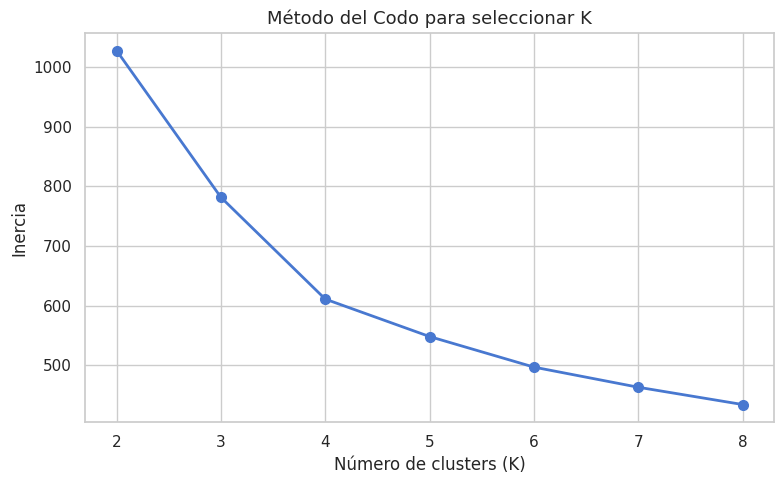

In [38]:
# MÉTODO DEL CODO
inercias = []

# Diferentes cantidades de grupos
K_range = range(2, 9)

for k in K_range:

    # Creamos el modelo K-Means
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Entrenar modelo
    km.fit(X_scaled)

    # Guardar la inercia
    inercias.append(km.inertia_)



# GRÁFICO
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    K_range,
    inercias,
    marker='o',
    linewidth=2,
    markersize=7
)

ax.set_title(
    'Método del Codo para seleccionar K',
    fontsize=13
)

ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Inercia')

ax.set_xticks(list(K_range))

plt.tight_layout()
plt.show()


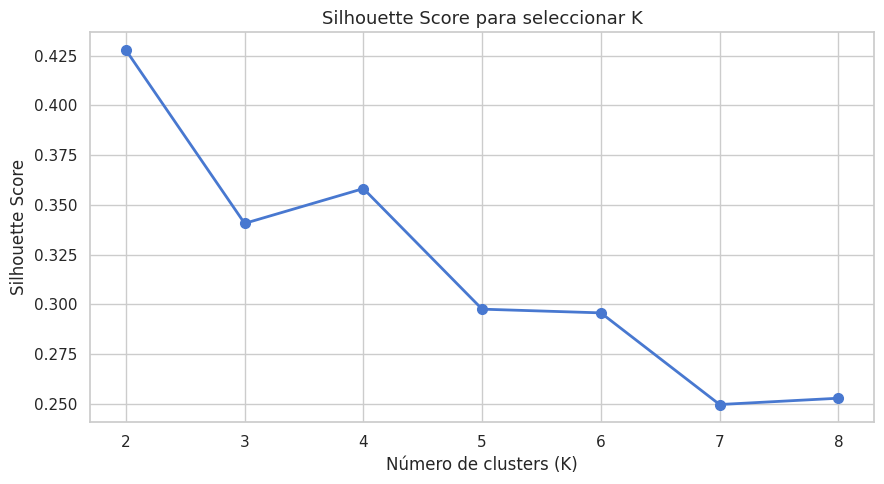

K = 2: Silhouette Score = 0.428
K = 3: Silhouette Score = 0.341
K = 4: Silhouette Score = 0.358
K = 5: Silhouette Score = 0.298
K = 6: Silhouette Score = 0.296
K = 7: Silhouette Score = 0.250
K = 8: Silhouette Score = 0.253


In [39]:
from sklearn.metrics import silhouette_score

# SILHOUETTE SCORE
silhouette_scores = []

K_range_sil = range(2, 9)

for k in K_range_sil:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)


# GRÁFICO
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    K_range_sil,
    silhouette_scores,
    marker='o',
    linewidth=2,
    markersize=7
)

ax.set_title(
    'Silhouette Score para seleccionar K',
    fontsize=13
)

ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Silhouette Score')

ax.set_xticks(list(K_range_sil))

plt.tight_layout()
plt.show()

# Mostrar valores
for k, score in zip(K_range_sil, silhouette_scores):
    print(f'K = {k}: Silhouette Score = {score:.3f}')

In [40]:
# ENTRENAMIENTO K-MEANS
K = 4

# Creamos el modelo K-Means
# random_state=42 garantiza que el resultado sea reproducible.
# n_init=10 prueba diferentes inicializaciones y selecciona la mejor.
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

# Creamos una copia del DataFrame de países
df_country = df_country.copy()

# Entrenamos K-Means y asignamos cada país a un cluster
df_country['cluster'] = kmeans.fit_predict(X_scaled)

print('Distribución de países por cluster:')
print(df_country['cluster'].value_counts().sort_index())

Distribución de países por cluster:
cluster
0    88
1    64
2     3
3    57
Name: count, dtype: int64


In [41]:
cluster_profile = (
    df_country
    .groupby('cluster')[features_cluster]
    .mean()
)

print('Perfil promedio de los clusters:')
print(cluster_profile.round(2))

Perfil promedio de los clusters:
         inflation_rate  unemployment_rate  fdi_pct_gdp  life_expectancy  \
cluster                                                                    
0                  6.37               9.27         4.09            71.33   
1                  9.01               6.25         3.71            58.86   
2                 35.14              10.29        -0.82            64.38   
3                  2.13               7.13         7.85            78.42   

         child_mortality  school_enrollment_secondary  internet_usage_pct  \
cluster                                                                     
0                  27.76                        82.00               27.65   
1                  91.14                        39.27                7.31   
2                  59.91                        42.26               12.48   
3                   6.36                       105.03               63.20   

         electricity_access_pct  digital_readin

In [42]:
# Países pertenecientes al cluster 2

paises_cluster_2 = df_country[
    df_country['cluster'] == 2
].index

print('Países del Cluster 2:')
print(list(paises_cluster_2))

Países del Cluster 2:
['Iraq', 'South Sudan', 'Suriname']


PC1 explica el 61.9% de la varianza
PC2 explica el 13.0% de la varianza
PC1 + PC2 explican el 74.9% de la varianza


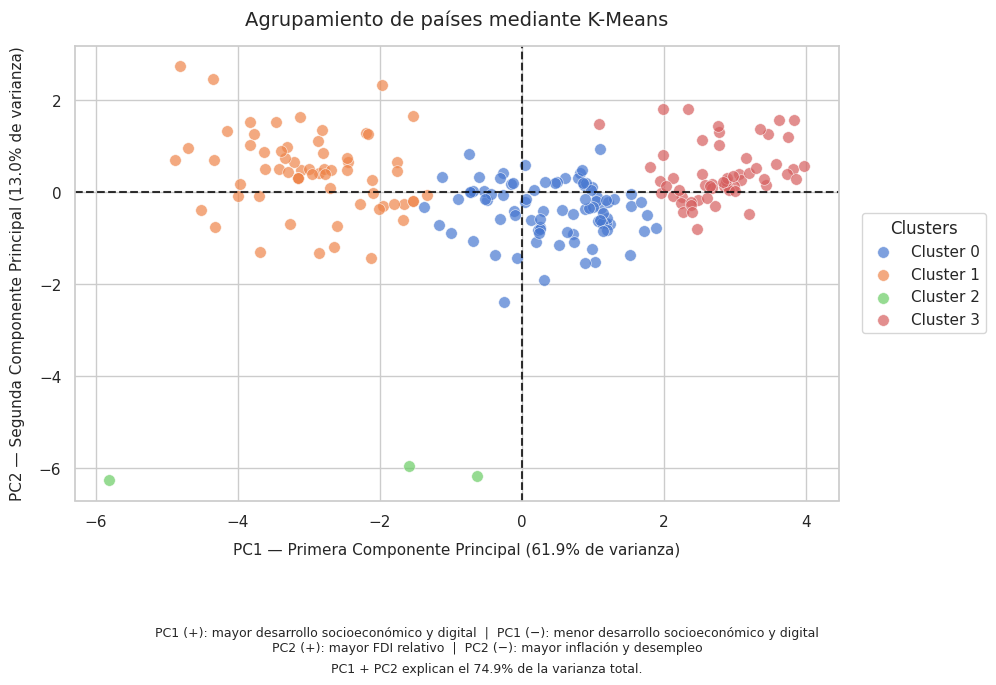

In [53]:
# VISUALIZACIÓN DE LOS CLUSTERS MEDIANTE PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)


# Porcentaje de varianza explicado
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
var_total = pca.explained_variance_ratio_.sum() * 100

print(f'PC1 explica el {var_pc1:.1f}% de la varianza')
print(f'PC2 explica el {var_pc2:.1f}% de la varianza')
print(f'PC1 + PC2 explican el {var_total:.1f}% de la varianza')



# GRÁFICO
fig, ax = plt.subplots(figsize=(11, 7))


# Graficar cluster
for i in range(K):

    mask = df_country['cluster'] == i

    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f'Cluster {i}',
        alpha=0.7,
        s=70,
        edgecolors='white',
        linewidths=0.5
    )



# EJES
# Línea horizontal: PC2 = 0
ax.axhline(
    0,
    linewidth=1.5,
    color='black' ,
    linestyle='--',
    alpha=0.8
)

# Línea vertical: PC1 = 0
ax.axvline(
    0,
    linewidth=1.5,
    color='black' ,
    linestyle='--',
    alpha=0.8
)


# TÍTULO
ax.set_title(
    'Agrupamiento de países mediante K-Means',
    fontsize=14,
    pad=15
)



# EJES

ax.set_xlabel(
    f'PC1 — Primera Componente Principal '
    f'({var_pc1:.1f}% de varianza)',
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    f'PC2 — Segunda Componente Principal '
    f'({var_pc2:.1f}% de varianza)',
    fontsize=11,
    labelpad=10
)



# LEYENDA

ax.legend(
    title='Clusters',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)



# CUADRO DEL GRÁFICO

for spine in ax.spines.values():
    spine.set_visible(True)



# INTERPRETACIÓN


#fig.text(
    0.5,
    0.065,
    #'Interpretación de los componentes:',
    #ha='center',
    #fontsize=10,
    #fontweight='bold'
#)

fig.text(
    0.5,
    0.035,
    'PC1 (+): mayor desarrollo socioeconómico y digital  |  '
    'PC1 (−): menor desarrollo socioeconómico y digital\n'
    'PC2 (+): mayor FDI relativo  |  '
    'PC2 (−): mayor inflación y desempleo',
    ha='center',
    fontsize=9
)

fig.text(
    0.5,
    0.005,
    f'PC1 + PC2 explican el {var_total:.1f}% de la varianza total.',
    ha='center',
    fontsize=9
)



# AJUSTE
plt.subplots_adjust(
    right=0.82,
    bottom=0.25,
    top=0.90
)

plt.show()

In [44]:
# CONTRIBUCIÓN DE CADA VARIABLE A LOS COMPONENTES PRINCIPALES

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features_cluster
)

print('Contribución de las variables a PC1 y PC2:')
print(loadings.round(3))

Contribución de las variables a PC1 y PC2:
                               PC1    PC2
inflation_rate              -0.233 -0.480
unemployment_rate            0.105 -0.528
fdi_pct_gdp                  0.085  0.648
life_expectancy              0.399 -0.025
child_mortality             -0.393  0.126
school_enrollment_secondary  0.400 -0.075
internet_usage_pct           0.387  0.083
electricity_access_pct       0.384 -0.197
digital_readiness_score      0.395  0.056


---
## 🏁 BLOQUE 5 — Síntesis

### Resumen de lo que aprendimos hoy

In [54]:
# Tabla resumen de las técnicas de aprendizaje automático utilizadas

resumen = pd.DataFrame({
    'Técnica': [
        'K-Means Clustering',
        'Regresión Lineal'
    ],

    'Tipo': [
        'No supervisado',
        'Supervisado'
    ],

    'Métrica principal': [
        'Silhouette Score / Inercia',
        'R² / RMSE'
    ],

    'Resultado': [
        'K = 4; 4 clusters interpretables',
        f'R² = {r2_lr:.3f}, RMSE = {rmse_lr:.1f} pts'
    ]
})

resumen

,Técnica,Tipo,Métrica principal,Resultado
0,K-Means Clustering,No supervisado,Silhouette Score / Inercia,K = 4; 4 clusters interpretables
1,Regresión Lineal,Supervisado,R² / RMSE,"R² = 0.681, RMSE = 10135.7 pts"


Generar un codigo en Python que lea un archivo y carge los datos usando Panda